# Introduction
This notebook analyzes the Zomato Bangalore dataset (51,000+ restaurants) to uncover insights about Bangalore's restaurant scene — popular locations, cuisines, ratings, and cost patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("zomato.csv")

In [5]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Data Cleaning

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [11]:
df['rate'].value_counts().head(10)

rate
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
3.8 /5    1851
3.7 /5    1810
3.6/5     1773
4.0/5     1609
4.0 /5    1574
Name: count, dtype: int64

In [12]:
df['rate']=df['rate'].str.replace('/5','').str.strip().str.replace(' ','')
df['rate']=pd.to_numeric(df['rate'],errors='coerce')

In [19]:
df['approx_cost(for two people)']=pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')

In [24]:
df['rate']=df['rate'].fillna(df['rate'].median())
df['approx_cost(for two people)']=df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].median())

In [25]:
df['rate'].isnull().sum()

np.int64(0)

In [26]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)        0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [ ]:
df.drop(['phone','dish_liked'],axis=1,inplace=True)

In [34]:
df.dropna(subset=['cuisines', 'location', 'rest_type'], inplace=True)

In [35]:
df.isnull().sum()

url                            0
address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
menu_item                      0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [38]:
df.head()

,url,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Exploratory Data Analysis (EDA)

# Q1. Which locations have most restaurants?

In [45]:
location_rest=df.groupby('location')[['name']].nunique().reset_index().sort_values('name',ascending=False).rename(columns={'name':'rest_count'}).head(15)
location_rest

,location,rest_count
89,Whitefield,817
0,BTM,696
19,Electronic City,692
22,HSR,681
56,Marathahalli,654
27,Indiranagar,524
29,JP Nagar,499
3,Bannerghatta Road,446
32,Jayanagar,351
6,Bellandur,346


Text(0.5, 1.0, 'No .of restaurants in each location')

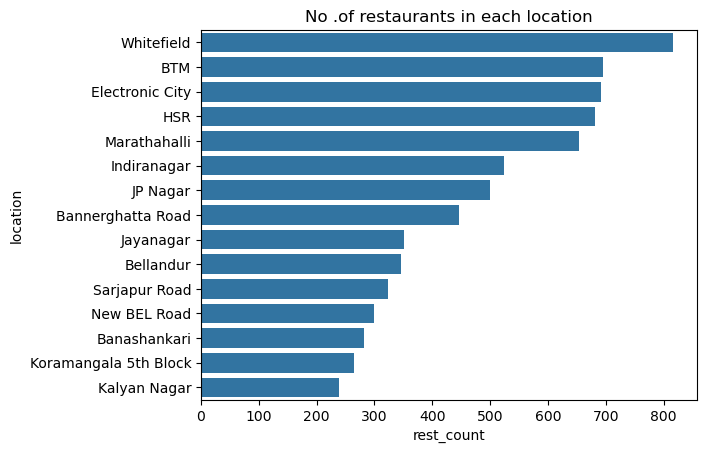

In [53]:
sns.barplot(data=location_rest,x='rest_count',y='location',errorbar=None)
plt.title("No .of restaurants in each location")

## Insights: Whitefield layout has the highest number of restaurants in Bangalore, followed by BTM and Electronic City — indicating these are the most competitive and densely populated food zones in the city.

# Q2. What is the distribution of ratings across restaurants?

<Axes: xlabel='rate', ylabel='Count'>

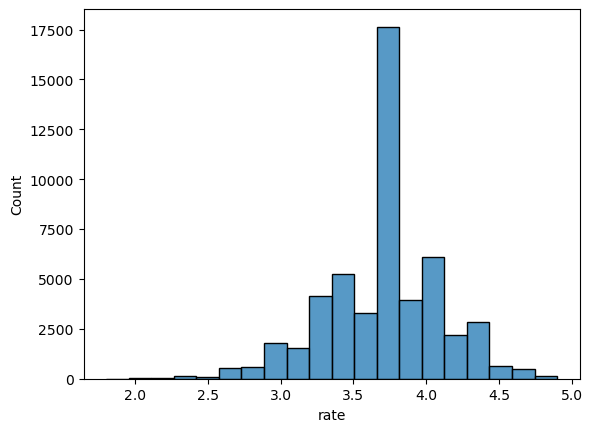

In [58]:
sns.histplot(data=df,x='rate',bins=20)

## Insight: Most restaurants are rated between 3.5 and 4.0, with 3.7 being the most common rating. Very few restaurants fall below 2.5 or above 4.5 — suggesting rating inflation is common on Zomato

# Q3. Does online ordering affect ratings?

Text(0.5, 1.0, 'Online ordering v/s ratings')

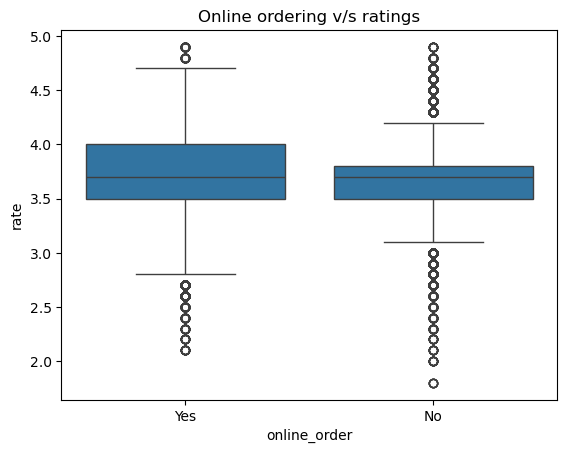

In [76]:
sns.boxplot(data=df,x='online_order',y='rate')
plt.title("Online ordering v/s ratings")

## Insight: Restaurants offering online ordering have a slightly higher median rating (~3.7) compared to those that don't (~3.6). However the difference is small — online ordering alone doesn't significantly impact ratings

# Q4. Which restaurant types are most common?

In [68]:
rest_types=df.groupby('rest_type')[['rate']].count().reset_index().sort_values('rate',ascending=False).rename(columns={'rate':'No. of orders'})
rest_types

,rest_type,No. of orders
78,Quick Bites,19129
27,Casual Dining,10326
19,Cafe,3732
39,Delivery,2595
40,Dessert Parlor,2262
...,...,...
45,"Dessert Parlor, Kiosk",2
54,"Food Court, Beverage Shop",2
72,Pop Up,2
84,"Quick Bites, Kiosk",1


Text(0.5, 1.0, 'Popular Restaurant types')

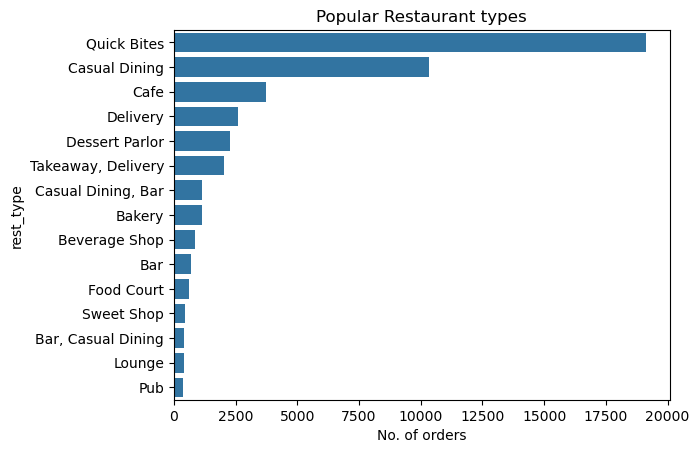

In [88]:
sns.barplot(data=rest_types.head(15),x='No. of orders',y='rest_type',orient='h')
plt.title("Popular Restaurant types")

## Insight: Quick Bites is by far the most common restaurant type in Bangalore, followed by Casual Dining — indicating most people prefer fast, affordable food over sit-down dining experiences.

# Q5. What are the most popular cuisines?

In [84]:
cuisine_counts = df['cuisines'].str.split(',').explode().str.strip().value_counts().reset_index()
cuisine_counts

,cuisines,count
0,North Indian,20961
1,Chinese,15462
2,South Indian,8626
3,Fast Food,8065
4,Biryani,6444
...,...,...
102,Sindhi,4
103,Hot dogs,3
104,Pan Asian,3
105,Indian,2


Text(0.5, 1.0, 'Top cuisines')

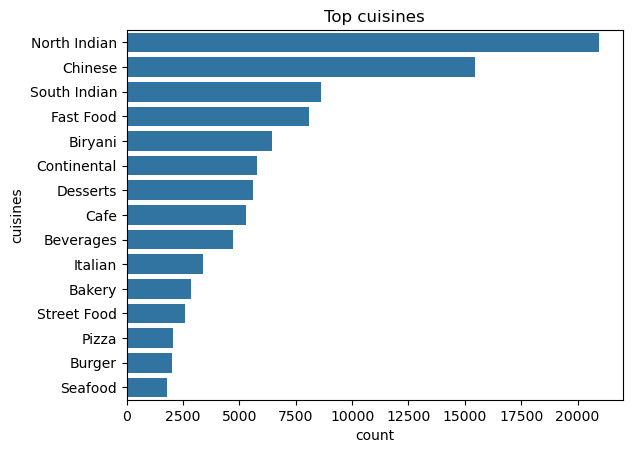

In [86]:
sns.barplot(data=cuisine_counts.head(15),x='count',y='cuisines',orient='h')
plt.title("Top cuisines")

## Insight: North Indian and Chinese cuisines dominate Bangalore's restaurant scene, followed by Fast Food and South Indian — reflecting both local taste preferences and the popularity of pan-Indian cuisine

# Q6. Does cost affect ratings- are expensive restaurants rated higher?

Text(0.5, 1.0, 'cost v/s ratings')

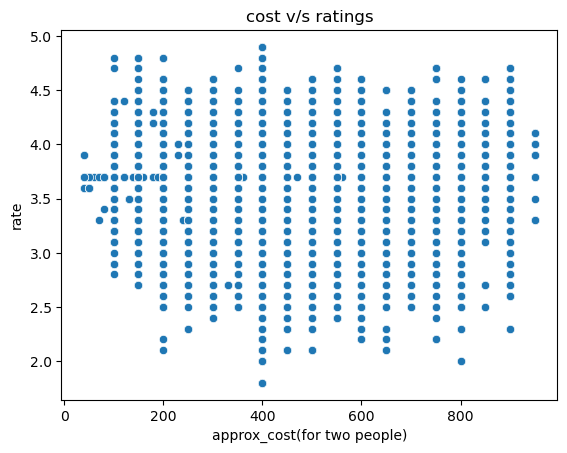

In [90]:
sns.scatterplot(data=df,x='approx_cost(for two people)',y='rate')
plt.title("cost v/s ratings")

## Insight: No clear correlation between cost and rating — expensive restaurants don't necessarily rate higher. Good food exists at all price points in Bangalore.

# Conclusion

- Whitefield Layout has the highest restaurant density, followed by BTM and Electronic city
- Most restaurants are rated between 3.5-4.0, with 3.7 being the most common rating
- Restaurants with online ordering have slightly higher ratings than those without
- Quick Bites is the most common restaurant type in Bangalore
- North Indian and Chinese are the most popular cuisines
- Cost has no clear correlation with ratings — good food exists at all price points